In [3]:
from typing import List, Dict, Any, Optional, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from duckduckgo_search import DDGS

llm = ChatOllama(model="llama3.1:8b", temperature=0.2)

In [17]:
import os
os.environ["LANGSMITH_API_KEY"]    = "YOUR-API-HERE"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]    = "cv-assistant"
os.environ["LANGCHAIN_ENDPOINT"]   = "https://api.smith.langchain.com"

print("Tracing:", os.environ["LANGCHAIN_TRACING_V2"])
print("Project:", os.environ["LANGCHAIN_PROJECT"])

Tracing: true
Project: cv-assistant


In [7]:
import fitz

def read_pdf_with_fitz(file_path):
    """
    Reads a PDF file and extracts all text using fitz (PyMuPDF).
    """
    text = ""
    try:
        with fitz.open(file_path) as doc:
            for page in doc:
                text += page.get_text()
    except Exception as e:
        print(f"Error reading PDF: {e}")
        return None
    return text
    


In [8]:
cv_text = read_pdf_with_fitz('Hisham Alfawzani cv.pdf')
print(cv_text[:500])

Hisham Alfawzani 
Saudi Arabia, Riyadh | +966 593305578 | AlfawzaniHisham@gmail.com | LinkedIn | GitHub 
 
Professional Summary: 
 
Computer Information Systems student at King Saud University specializing in AI and Machine Learning.  
Experienced in building LLM applications including RAG systems and fine-tuning models with LoRA.  
Seeking an AI/ML internship to apply machine learning and LLM engineering skills in real-world systems 
Education: 
- 
BA in Computer Information Systems | King Saud


In [49]:
class GraphState(TypedDict):
    cv_text: str
    job_title: str
    cv_analysis: Optional[Dict]
    job_requirements: Optional[Dict]
    gaps: Optional[Dict]
    improvements: Optional[str]
    critique: Optional[Dict]
    iteration:int
    max_iteration: int

In [56]:
ANALYZER_SYSTEM = """You are a CV Analyzer Agent.
Read the CV text carefully and extract:
- Technical and soft skills
- Work experience (company, role, duration)
- Education background
- Projects (title, description, technologies used)
- A brief professional summary

Rules:
- Extract only what is written in the CV, do not add anything
- Be specific and detailed
- Return valid JSON matching the schema
"""
JOB_SEARCH_SYSTEM = """You are a Job Search Agent.
Read the job_title and summarize the key requirements for this role.

Rules:
- Extract requirements from the search results only
- Be specific: list required skills, experience, and qualifications
- Do not add anything not mentioned in the search results
- Return valid JSON matching the schema
"""
GAP_SYSTEM="""You are a Gap Analysis Agent.
compare the candicate CV analsyis with the job requirements.

Rules:
- Treat projects as practical experience, not just academic work
- List skills and experience the candidate is missing
- List skills and experience the candidate already has
- Be specific and honest
- Return valid JSON matching the schema
"""

IMPROVER_SYSTEM = """You are a CV Improver Agent.
Based on the CV analysis and the identified gaps, write improvement suggestions.

Rules:
- Start with MISSING SKILLS section: list exactly what skills the candidate needs to add
- Then PRESENTATION section: how to present existing experience better
- Be specific: mention exact skills from the gaps analysis
- Suggest how to quantify achievements with real numbers
- Write in clear professional English
- Do not fabricate experience the candidate does not have
"""

VALIDATOR_SYSTEM = """You are a Validator Agent.
Review the improvement suggestions and score them.

Scoring criteria:
- Score 80-100: suggestions are specific, actionable, and address the gaps
- Score 60-79: suggestions are good but missing some details
- Score 40-59: suggestions are vague or incomplete
- Score 0-39: suggestions do not address the gaps

Rules:
- Be fair and realistic
- If missing skills are mentioned AND presentation tips are given = minimum score 70
- Return valid JSON matching the schema
"""

In [50]:
class CVAnalysis(BaseModel):
    skills: List[str]=Field(...,description="Technical and soft skills")
    experience: List[str]=Field(...,description="Work Experience")
    education: List[str] = Field(..., description="Education background")    
    summary:str= Field(..., description="Brief professional summary")
    region: str= Field(..., description="Candidate's location or region extracted from CV")
    projects: List[str] = Field(..., description="List of projects with title, description, and technologies used")
class JobRequirements(BaseModel):
    required_skills: List[str] = Field(..., description="Must-have skills")
    preferred_skills: List[str] = Field(..., description="Nice-to-have skills")
    experience_years: str= Field(..., description="Years of experience required")
    education_required: str = Field(..., description="Education requirement")

class GapAnalysis(BaseModel):
    existing_skills: List[str] = Field(..., description="Skills candidate already has")
    missing_experience: List[str] = Field(..., description="Experience gaps")
    missing_skills: List[str] = Field(..., description="Skills candidate is missing")

class Validation(BaseModel):
    issues:           List[str] = Field(..., description="Problems with the improvements")
    score:            int       = Field(..., ge=0, le=100, description="Quality score")
    fix_instructions: List[str] = Field(..., description="How to improve")

In [47]:
def analyzer_node(state: GraphState) -> GraphState:
    structured_analyzer = llm.with_structured_output(CVAnalysis)
    result = structured_analyzer.invoke([
        SystemMessage(content=ANALYZER_SYSTEM),
        HumanMessage(content=state['cv_text'])
    ])
    state['cv_analysis'] = result.model_dump()
    print(f'Skills found: {len(result.skills)}')
    print(f'Experience: {len(result.experience)}')
    return state


def job_search_node(state: GraphState) -> GraphState:
    region = state['cv_analysis'].get('region', 'Saudi Arabia')
    with DDGS() as ddgs:
        raw = list(ddgs.text(
            state['job_title'] + ' job requirements ' + region + ' 2026',
            max_results=3
        ))

    context = '\n\n'.join([r.get('body', '') for r in raw])

    structured_job = llm.with_structured_output(JobRequirements)
    result = structured_job.invoke([
        SystemMessage(content=JOB_SEARCH_SYSTEM),
        HumanMessage(content=f"""
Job Title: {state['job_title']}
Region: {region}
Search Results:
{context}
""")
    ])
    state['job_requirements'] = result.model_dump()
    print(f'Region: {region}')
    print(f'Required skills: {len(result.required_skills)}')
    return state

def gap_node(state: GraphState) -> GraphState:
    structured_gap = llm.with_structured_output(GapAnalysis)
    result = structured_gap.invoke([
        SystemMessage(content=GAP_SYSTEM),
        HumanMessage(content=f'CV Analysis:\n{state["cv_analysis"]}\n\nJob Requirements:\n{state["job_requirements"]}')
    ])
    state['gaps'] = result.model_dump()
    print(f'Missing skills: {len(result.missing_skills)}')
    print(f'Existing skills: {len(result.existing_skills)}')
    return state


def improver_node(state: GraphState) -> GraphState:
    resp = llm.invoke([
        SystemMessage(content=IMPROVER_SYSTEM),
        HumanMessage(content=f'CV Analysis:\n{state["cv_analysis"]}\n\nJob Requirements:\n{state["job_requirements"]}\n\nGaps:\n{state["gaps"]}')
    ]).content
    state['improvements'] = resp
    return state


def validator_node(state: GraphState) -> GraphState:
    improvements = state.get('improvements', None)
    if not improvements:
        state['critique'] = {'score': 0, 'issues': [], 'fix_instructions': []}
        state['iteration'] += 1
        return state
    structured_validator = llm.with_structured_output(Validation)
    result = structured_validator.invoke([
        SystemMessage(content=VALIDATOR_SYSTEM),
        HumanMessage(content=f"""
Improvements:
{improvements}

CV Analysis:
{state['cv_analysis']}

Job Requirements:
{state['job_requirements']}

Gaps:
{state['gaps']}
""")
    ])
    state['critique']  = result.model_dump()
    state['iteration'] += 1
    print(f'Validation score: {result.score} | iteration: {state["iteration"]}')
    return state

In [42]:
def should_revise(state: GraphState) -> Literal['revise', 'finalize']:
    score = state['critique']['score']

    if state['iteration'] >= state['max_iteration']:
        return 'finalize'

    if score < 80:
        return 'revise'

    return 'finalize'

In [43]:
workflow =StateGraph(GraphState)

workflow.add_node('analyzer',analyzer_node)
workflow.add_node('job_search',job_search_node)
workflow.add_node('gap', gap_node)
workflow.add_node('improver', improver_node)
workflow.add_node('validator',validator_node)

workflow.set_entry_point('analyzer')
workflow.add_edge('analyzer','job_search')
workflow.add_edge('job_search','gap')
workflow.add_edge('gap',       'improver')
workflow.add_edge('improver','validator')
workflow.add_conditional_edges(
    'validator',
    should_revise,
    {
        'revise':   'improver',
        'finalize': END,
    }
)

In [57]:
app = workflow.compile()

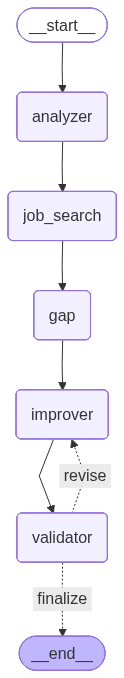

In [45]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print('Graph visualization skipped:', e)

In [58]:
initial_state: GraphState = {
    'cv_text':          cv_text,
    'job_title':        'Data Scientist Intern',
    'cv_analysis':      None,
    'job_requirements': None,
    'gaps':             None,
    'improvements':     None,
    'critique':         None,
    'iteration':        0,
    'max_iteration':    2,
}

result = app.invoke(initial_state)
print(result['improvements'])

Skills found: 5
Experience: 0


/tmp/ipykernel_688/2541204783.py:15: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Region: Saudi Arabia, Riyadh
Required skills: 5
Missing skills: 1
Existing skills: 5
Validation score: 90 | iteration: 1
**MISSING SKILLS**

To make the candidate's CV more competitive for the job requirements, they need to add the following skills:

* Statistics
* Data Visualization

These skills are essential for the role and can be demonstrated through relevant coursework, projects, or certifications. The candidate should focus on acquiring these skills to bridge the gap.

**PRESENTATION**

To present existing experience better, consider the following suggestions:

1. **Quantify achievements**: Instead of stating "Completed" for each project, provide specific metrics that demonstrate the impact and success of each project. For example:
	* Local-LLM-RAG-System: "Improved question-answer accuracy by 25% using multilingual-e5-small embeddings with ChromaDB."
	* Stripe Documentation Chatbot – RAG: "Reduced response time by 30% using Sentence Transformers for retrieval and Qwen2.5-1.5B f